# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [22]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [23]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

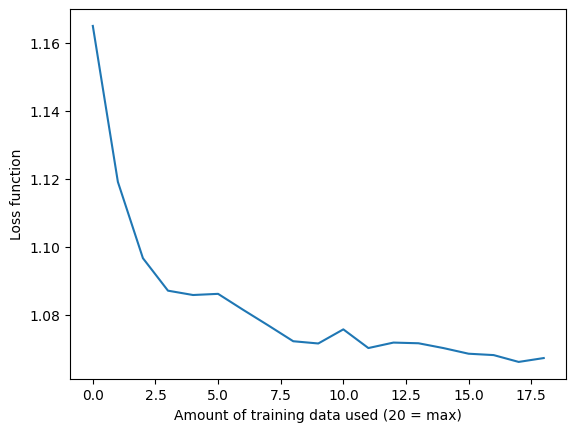

In [24]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [25]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

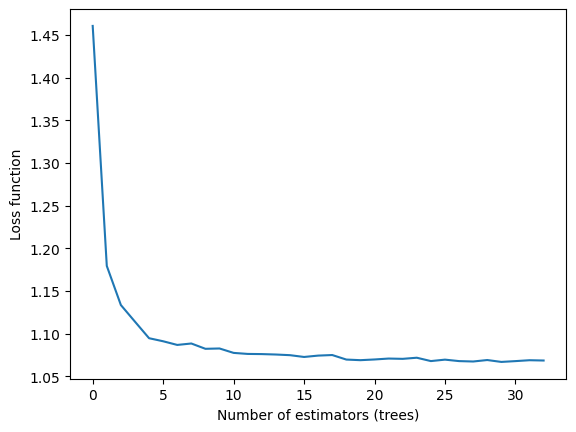

In [26]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

If I were to cut one of the graphs, it would be the second graph since the first graph gives insight into overall model behavior rather than a single hyperparameter. While tuning the number of trees is important, understanding whether the model is still learning, underfitting, or plateauing is arguably more important, which is what the first graph illustrates. By understanding how the loss function decreases as more training data is used can help understand whether or not it is worth acquiring more training data or whether the current level is sufficient. In this case, it looks as though the loss function is hitting a plateau as the training set increases, but it may be too early to tell. A broader discussion would need to be had regarding the feasibility of getting more data, and whether the subsequent decrease in the loss function would be worth the effort.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import chardet

In [40]:
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedKFold,GridSearchCV, RandomizedSearchCV

In [49]:
def run_rf(X_train, y_train):    
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
    }

    # Initialize the RandomForestRegressor
    forest_regressor = RandomForestRegressor(random_state=42)

    # Perform RandomizedSearch CV
    rand_search = RandomizedSearchCV(
        estimator=forest_regressor,
        param_distributions=param_grid,
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1
    )

    rand_search.fit(X_train, y_train)

    # Extract the results
    results = pd.DataFrame(rand_search.cv_results_)
    results["MSE"] = -results["mean_test_score"]
    results["RMSE"] = np.sqrt(results["MSE"])
    results_sorted = results.sort_values("RMSE").head(10)  # Top 10 results
    
    return results_sorted

In [28]:
file_path = 'IRENA_RenewableEnergy_Statistics_2000-2022.csv'

with open(file_path, 'rb') as f:
    result = chardet.detect(f.read())

irena = pd.read_csv(file_path, encoding=result['encoding'])

irena.head()

,Region,Sub-region,Country,ISO3 code,M49 code,RE or Non-RE,Group Technology,Technology,Producer Type,Year,Electricity Generation (GWh),Electricity Installed Capacity (MW)
0,Africa,Northern Africa,Algeria,DZA,12,Total Non-Renewable,Fossil fuels,Natural gas,On-grid electricity,2000,24585.0,5459.01
1,Africa,Northern Africa,Algeria,DZA,12,Total Non-Renewable,Fossil fuels,Natural gas,On-grid electricity,2001,25781.0,5455.50
2,Africa,Northern Africa,Algeria,DZA,12,Total Non-Renewable,Fossil fuels,Natural gas,On-grid electricity,2002,26994.0,5891.01
3,Africa,Northern Africa,Algeria,DZA,12,Total Non-Renewable,Fossil fuels,Natural gas,On-grid electricity,2003,28619.4,6013.24
4,Africa,Northern Africa,Algeria,DZA,12,Total Non-Renewable,Fossil fuels,Natural gas,On-grid electricity,2004,30312.0,6305.24


In [31]:
X = irena.drop(columns=['Electricity Generation (GWh)'])
y = irena['Electricity Generation (GWh)']

In [43]:
# Convert categorical features to numeric using one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Update the train-test split with the encoded features
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [50]:
run_rf(X_train, y_train)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,MSE,RMSE
1,83.357512,2.049984,0.312812,0.021269,100,2,None,"{'n_estimators': 100, 'min_samples_split': 2, ...",-2.286391e+08,-8.296281e+07,-1.377777e+08,-2.341773e+08,-2.157779e+08,-1.798670e+08,5.963197e+07,1,1.798670e+08,13411.449183
5,63.800960,0.977284,0.115720,0.014596,100,2,20,"{'n_estimators': 100, 'min_samples_split': 2, ...",-2.298487e+08,-8.319588e+07,-1.384698e+08,-2.457767e+08,-2.110511e+08,-1.816684e+08,6.141257e+07,2,1.816684e+08,13478.443288
2,29.596401,0.984877,0.059249,0.009152,100,2,10,"{'n_estimators': 100, 'min_samples_split': 2, ...",-2.577900e+08,-1.153501e+08,-1.698076e+08,-2.842771e+08,-2.546247e+08,-2.163699e+08,6.350354e+07,3,2.163699e+08,14709.517660
8,102.026637,4.451168,0.287542,0.047066,200,5,None,"{'n_estimators': 200, 'min_samples_split': 5, ...",-4.282228e+08,-9.250660e+07,-1.551933e+08,-1.992381e+08,-2.116811e+08,-2.173684e+08,1.133815e+08,4,2.173684e+08,14743.417708
9,11.828438,0.871926,0.027771,0.003772,50,2,10,"{'n_estimators': 50, 'min_samples_split': 2, '...",-2.349298e+08,-1.161643e+08,-1.623099e+08,-3.023935e+08,-2.726673e+08,-2.176930e+08,6.909243e+07,5,2.176930e+08,14754.421764
0,123.034283,0.455530,0.210457,0.023765,200,5,20,"{'n_estimators': 200, 'min_samples_split': 5, ...",-4.309545e+08,-9.225493e+07,-1.565475e+08,-1.996686e+08,-2.106404e+08,-2.180132e+08,1.143049e+08,6,2.180132e+08,14765.269244
6,74.180493,6.436429,0.212611,0.048529,100,5,None,"{'n_estimators': 100, 'min_samples_split': 5, ...",-4.173818e+08,-9.009105e+07,-1.527460e+08,-2.105328e+08,-2.306347e+08,-2.202773e+08,1.100558e+08,7,2.202773e+08,14841.741190
7,49.141644,0.682775,0.075847,0.006326,200,10,10,"{'n_estimators': 200, 'min_samples_split': 10,...",-5.367229e+08,-1.375272e+08,-2.428252e+08,-2.976018e+08,-2.989827e+08,-3.027320e+08,1.308996e+08,8,3.027320e+08,17399.194191
3,27.411801,0.306358,0.044603,0.004751,200,10,5,"{'n_estimators': 200, 'min_samples_split': 10,...",-7.174603e+08,-4.019935e+08,-4.918486e+08,-5.510904e+08,-6.012209e+08,-5.527227e+08,1.057527e+08,9,5.527227e+08,23510.056276
4,13.871802,0.308350,0.029139,0.005150,100,10,5,"{'n_estimators': 100, 'min_samples_split': 10,...",-7.187767e+08,-4.026107e+08,-4.920253e+08,-5.741148e+08,-6.127710e+08,-5.600597e+08,1.073182e+08,10,5.600597e+08,23665.580129


In [56]:
irena.describe()

,M49 code,Year,Electricity Generation (GWh),Electricity Installed Capacity (MW)
count,35193.000000,35193.000000,3.519300e+04,3.159400e+04
mean,420.592618,2012.283437,1.440929e+04,3.452455e+03
std,252.192524,6.499073,1.148906e+05,2.715673e+04
min,4.000000,2000.000000,-5.874050e+02,1.000000e-03
25%,203.000000,2007.000000,1.168300e+01,5.000000e+00
50%,404.000000,2013.000000,2.002570e+02,5.890000e+01
75%,634.000000,2018.000000,2.383631e+03,6.325750e+02
max,894.000000,2022.000000,5.220700e+06,1.155325e+06


In [51]:
file_path_1 = 'organised_Gen.csv'

with open(file_path_1, 'rb') as f:
    result = chardet.detect(f.read())

us_data = pd.read_csv(file_path_1, encoding=result['encoding'])

us_data

,Unnamed: 0,YEAR,MONTH,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (Megawatthours)
0,0,2001,1,AK,Total Electric Power Industry,Coal,46903.0
1,1,2001,1,AK,Total Electric Power Industry,Petroleum,71085.0
2,2,2001,1,AK,Total Electric Power Industry,Natural Gas,367521.0
3,3,2001,1,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0
4,4,2001,1,AK,Total Electric Power Industry,Wind,87.0
...,...,...,...,...,...,...,...
496769,10581,2022,5,WY,"Electric Generators, Electric Utilities",Coal,2071403.0
496770,10582,2022,5,WY,"Electric Generators, Electric Utilities",Hydroelectric Conventional,96790.0
496771,10583,2022,5,WY,"Electric Generators, Electric Utilities",Natural Gas,91570.0
496772,10584,2022,5,WY,"Electric Generators, Electric Utilities",Petroleum,1812.0


In [52]:
us_data.drop(columns=['Unnamed: 0'],inplace=True)

In [53]:
X = us_data.drop(columns=['GENERATION (Megawatthours)'])
y = us_data['GENERATION (Megawatthours)']
X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [54]:
run_rf(X_train, y_train)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,MSE,RMSE
6,473.589026,8.992697,11.802927,0.798345,200,5,None,"{'n_estimators': 200, 'min_samples_split': 5, ...",-2.810996e+11,-3.059065e+11,-2.644907e+11,-2.596281e+11,-2.934119e+11,-2.809074e+11,1.734170e+10,1,2.809074e+11,5.300070e+05
5,130.281127,1.548370,2.439084,0.347897,50,10,None,"{'n_estimators': 50, 'min_samples_split': 10, ...",-3.779058e+11,-4.021175e+11,-3.701080e+11,-3.319269e+11,-3.766739e+11,-3.717464e+11,2.268437e+10,2,3.717464e+11,6.097101e+05
3,350.653821,1.192332,3.650459,0.227205,200,2,20,"{'n_estimators': 200, 'min_samples_split': 2, ...",-6.079862e+11,-6.382249e+11,-5.953953e+11,-5.819329e+11,-6.345321e+11,-6.116143e+11,2.186577e+10,3,6.116143e+11,7.820577e+05
9,124.364388,6.954664,0.724011,0.069315,100,10,20,"{'n_estimators': 100, 'min_samples_split': 10,...",-6.790995e+11,-7.294557e+11,-6.815011e+11,-6.487280e+11,-6.941622e+11,-6.865893e+11,2.611641e+10,4,6.865893e+11,8.286068e+05
8,88.101285,1.239127,0.469506,0.030464,100,5,10,"{'n_estimators': 100, 'min_samples_split': 5, ...",-1.239532e+13,-1.244115e+13,-1.256739e+13,-1.309644e+13,-1.572810e+13,-1.324568e+13,1.266105e+12,5,1.324568e+13,3.639461e+06
4,187.163890,12.053883,0.946141,0.076485,200,2,10,"{'n_estimators': 200, 'min_samples_split': 2, ...",-1.239470e+13,-1.242485e+13,-1.257109e+13,-1.311430e+13,-1.574302e+13,-1.324959e+13,1.273334e+12,6,1.324959e+13,3.639999e+06
7,178.036931,1.173160,0.982197,0.060760,200,5,10,"{'n_estimators': 200, 'min_samples_split': 5, ...",-1.239936e+13,-1.243344e+13,-1.256879e+13,-1.311922e+13,-1.574255e+13,-1.325267e+13,1.271556e+12,7,1.325267e+13,3.640422e+06
0,99.164201,0.177896,0.450663,0.021533,100,10,10,"{'n_estimators': 100, 'min_samples_split': 10,...",-1.242255e+13,-1.247304e+13,-1.260879e+13,-1.311195e+13,-1.574720e+13,-1.327271e+13,1.261109e+12,8,1.327271e+13,3.643172e+06
2,92.954994,3.157593,0.458043,0.045130,200,5,5,"{'n_estimators': 200, 'min_samples_split': 5, ...",-1.678977e+13,-1.754094e+13,-1.794222e+13,-1.793407e+13,-2.157667e+13,-1.835673e+13,1.663691e+12,9,1.835673e+13,4.284476e+06
1,25.696164,0.890276,0.128058,0.011101,50,10,5,"{'n_estimators': 50, 'min_samples_split': 10, ...",-1.685126e+13,-1.757388e+13,-1.794492e+13,-1.797882e+13,-2.147374e+13,-1.836452e+13,1.606681e+12,10,1.836452e+13,4.285385e+06


In [55]:
us_data.describe()

,YEAR,MONTH,GENERATION (Megawatthours)
count,496774.000000,496774.000000,4.967740e+05
mean,2011.649768,6.431452,1.393384e+06
std,6.168041,3.458944,1.078685e+07
min,2001.000000,1.000000,-9.978550e+05
25%,2006.000000,3.000000,1.643000e+03
50%,2012.000000,6.000000,2.330103e+04
75%,2017.000000,9.000000,2.792042e+05
max,2022.000000,12.000000,4.217967e+08


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

In [4]:
import matplotlib.pyplot as plt

In [14]:
def dollar_format(x, pos):
    return f'${x:,.0f}'

In [15]:
import matplotlib.ticker as mticker

<function matplotlib.pyplot.show(close=None, block=None)>

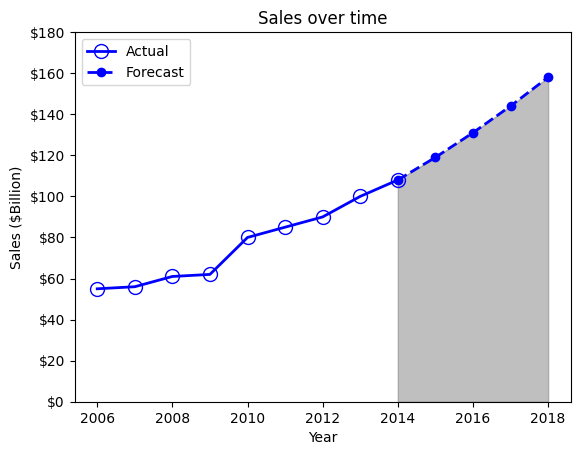

In [21]:
# Figure 6.2 pp. 154

x1 = np.arange(2006, 2015)
x2 = np.arange(2014, 2019)
y1 = [55, 56, 61, 62, 80, 85, 90, 100, 108]
y2 = [108, 119, 131, 144, 158]

plt.plot(x1, y1, color = "blue", label = "Actual", linewidth = 2, marker = 'o', fillstyle= 'none', markersize = 10)
plt.plot(x2, y2, color = "blue", label = "Forecast", linestyle = "--", linewidth = 2, marker='o')
plt.fill_between(x2, y2, where=(x2 >= 2014), color='grey', alpha=0.5)

plt.xlabel("Year")
plt.ylabel("Sales ($Billion)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
plt.ylim(0, 180)
plt.title("Sales over time")

plt.legend()
plt.show